# ARIA v5.0：馬太鞍三幕稽核器

本 notebook 依照 **Week 8 Assignment: ARIA v5.0 — The Matai'an Three-Act Auditor** 重新撰寫，不沿用舊版骨架。  
目標是用 **Sentinel-2 L2A + STAC API + 多圖層空間稽核**，重建 2025 年馬太鞍溪堰塞湖事件的三幕證據鏈，並完成 **Eyewitness Impact Table** 與 **Coverage Gap Analysis**。


## 0. Captain's Log
這份 notebook 的流程分成六段：  
1. 環境與參數設定  
2. 三幕場景搜尋與快速 QA  
3. 讀取 Pre / Mid / Post cube  
4. 四種 change metrics 與三種 detection masks  
5. 向量化與 multi-layer audit  
6. AI Advisor prompt 與輸出整理


In [39]:
# 0. Environment and imports
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape, box
from shapely.ops import unary_union

from dotenv import load_dotenv

import pystac_client
import planetary_computer as pc
import stackstac

warnings.filterwarnings("ignore", category=UserWarning)

load_dotenv()

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Environment loaded")
print("Output dir:", OUTPUT_DIR.resolve())


✅ Environment loaded
Output dir: D:\Class_satellite\HW8\output


## 1. Load `.env` and define constants
這一步把作業要求的 STAC、日期視窗、BBOX、EPSG、雲量門檻讀進來，後面所有 cell 都共用這組參數。

In [40]:
# 1. Parameters from .env
STAC_ENDPOINT = os.getenv("STAC_ENDPOINT", "https://planetarycomputer.microsoft.com/api/stac/v1")
S2_COLLECTION = os.getenv("S2_COLLECTION", "sentinel-2-l2a")
S2_BANDS = [b.strip() for b in os.getenv("S2_BANDS", "B02,B03,B04,B08,B11,B12").split(",")]

MATAIAN_BBOX = tuple(float(v) for v in os.getenv("MATAIAN_BBOX", "121.28,23.56,121.52,23.76").split(","))
TARGET_EPSG = int(os.getenv("TARGET_EPSG", "32651"))

PRE_RANGE = f"{os.getenv('PRE_EVENT_START','2025-06-01')}/{os.getenv('PRE_EVENT_END','2025-07-15')}"
MID_RANGE = f"{os.getenv('MID_EVENT_START','2025-08-01')}/{os.getenv('MID_EVENT_END','2025-09-20')}"
POST_RANGE = f"{os.getenv('POST_EVENT_START','2025-09-25')}/{os.getenv('POST_EVENT_END','2025-11-15')}"

PRE_CLOUD_MAX = int(os.getenv("PRE_CLOUD_MAX", os.getenv("S2_CLOUD_MAX", "20")))
MID_CLOUD_MAX = int(os.getenv("MID_CLOUD_MAX", "40"))
POST_CLOUD_MAX = int(os.getenv("POST_CLOUD_MAX", "30"))

FIXED_PRE_ITEM_ID = os.getenv("PRE_ITEM_ID", "").strip() or None
FIXED_MID_ITEM_ID = os.getenv("MID_ITEM_ID", "").strip() or None
FIXED_POST_ITEM_ID = os.getenv("POST_ITEM_ID", "").strip() or None

print("STAC_ENDPOINT =", STAC_ENDPOINT)
print("Collection =", S2_COLLECTION)
print("BBox =", MATAIAN_BBOX)
print("EPSG =", TARGET_EPSG)
print("Ranges =", PRE_RANGE, MID_RANGE, POST_RANGE)
print("Cloud max =", PRE_CLOUD_MAX, MID_CLOUD_MAX, POST_CLOUD_MAX)
print("Fixed IDs =", FIXED_PRE_ITEM_ID, FIXED_MID_ITEM_ID, FIXED_POST_ITEM_ID)


STAC_ENDPOINT = https://planetarycomputer.microsoft.com/api/stac/v1
Collection = sentinel-2-l2a
BBox = (121.28, 23.56, 121.52, 23.76)
EPSG = 32651
Ranges = 2025-06-01/2025-07-15 2025-08-01/2025-09-20 2025-09-25/2025-11-15
Cloud max = 20 40 30
Fixed IDs = None None None


## 2. Helper functions
這裡集中定義 STAC 搜尋、TCI 預覽、cube 讀取、指標計算、向量化與輸出用的函式，避免後面重複寫。

In [41]:
# 2. Helper functions
CATALOG = pystac_client.Client.open(STAC_ENDPOINT, modifier=pc.sign_inplace)

def robust_search(bbox, date_range, cloud_max=20, max_retries=4, sleep_base=1.5):
    """Client-side cloud filtering with retry/backoff."""
    last_error = None
    for attempt in range(max_retries):
        try:
            search = CATALOG.search(
                collections=[S2_COLLECTION],
                bbox=bbox,
                datetime=date_range,
            )
            items = list(search.items())
            items = [it for it in items if it.properties.get("eo:cloud_cover", 999) <= cloud_max]
            items = sorted(items, key=lambda it: (it.properties.get("eo:cloud_cover", 999), it.id))
            return items
        except Exception as e:
            last_error = e
            time.sleep(sleep_base * (2 ** attempt))
    raise RuntimeError(f"STAC search failed after retries: {last_error}")

def fetch_item_by_id(item_id):
    search = CATALOG.search(collections=[S2_COLLECTION], ids=[item_id])
    items = list(search.items())
    if len(items) == 0:
        raise ValueError(f"Item ID not found: {item_id}")
    return items[0]

def _signed_visual_href(item):
    signed = pc.sign(item)
    return signed.assets["visual"].href

def preview_item_visual(item, ax, title_prefix=""):
    """Quick TCI preview using the visual asset."""
    href = _signed_visual_href(item)
    with rxr.open_rasterio(href, overview_level=3, masked=True) as img:
        rgb = img.isel(band=slice(0, 3)).transpose("y", "x", "band").values.astype("float32")
        rgb = np.nan_to_num(rgb, nan=0.0)
        if np.nanmax(rgb) > 1.5:
            rgb = rgb / 255.0
        ax.imshow(rgb)
    dt = str(item.properties.get("datetime", ""))[:10]
    cc = item.properties.get("eo:cloud_cover", "N/A")
    ax.set_title(f"{title_prefix}{item.id}\nCloud: {cc}% | {dt}", fontsize=9)
    ax.axis("off")

def choose_item(items, fixed_id=None):
    if fixed_id:
        return fetch_item_by_id(fixed_id)
    if len(items) == 0:
        raise ValueError("No items available to choose from.")
    return items[0]

def stream_cube(item, bands=None, bbox=None, epsg=None, resolution=10, chunksize=1024):
    """Read a freshly signed Sentinel-2 item as surface reflectance cube (0-1 scale)."""
    bands = bands or S2_BANDS
    bbox = bbox or MATAIAN_BBOX
    epsg = int(epsg or TARGET_EPSG)
    signed = pc.sign(item)
    cube = stackstac.stack(
        [signed],
        assets=bands,
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=tuple(bbox),
        chunksize=chunksize,
        dtype="float32",
        fill_value=np.float32(np.nan),
        rescale=False,
    ).squeeze("time", drop=True) / 10000.0
    return cube.astype("float32")

def composite_stretched(cube, r="B04", g="B03", b="B02", lo=2, hi=98):
    r_arr = cube.sel(band=r).compute().values
    g_arr = cube.sel(band=g).compute().values
    b_arr = cube.sel(band=b).compute().values
    rgb = np.stack([r_arr, g_arr, b_arr], axis=-1).astype("float32")
    out = np.zeros_like(rgb, dtype="float32")
    for k in range(3):
        band = rgb[..., k]
        vmin, vmax = np.nanpercentile(band, [lo, hi])
        out[..., k] = np.clip((band - vmin) / max(vmax - vmin, 1e-6), 0, 1)
    return out

def save_local_preview(cube, out_path, downsample=4):
    cube_preview = cube.coarsen(x=downsample, y=downsample, boundary="trim").mean()
    rgb = composite_stretched(cube_preview, "B04", "B03", "B02")
    plt.imsave(out_path, rgb)
    return out_path

def ndvi(cube):
    nir = cube.sel(band="B08")
    red = cube.sel(band="B04")
    return (nir - red) / (nir + red + 1e-6)

def bsi(cube):
    swir = cube.sel(band="B11")
    red = cube.sel(band="B04")
    nir = cube.sel(band="B08")
    blue = cube.sel(band="B02")
    return ((swir + red) - (nir + blue)) / ((swir + red) + (nir + blue) + 1e-6)

def nir_drop(pre, post):
    return pre.sel(band="B08") - post.sel(band="B08")

def swir_post(post):
    return post.sel(band="B12")

def bsi_change(pre, post):
    return bsi(post) - bsi(pre)

def ndvi_change(pre, post):
    return ndvi(pre) - ndvi(post)

def blue_mid(mid):
    return mid.sel(band="B02")

def green_mid(mid):
    return mid.sel(band="B03")

def pixel_area_km2(mask_da):
    resx = abs(float(mask_da.x[1] - mask_da.x[0]))
    resy = abs(float(mask_da.y[1] - mask_da.y[0]))
    px_area_m2 = resx * resy
    count = int(np.nansum(mask_da.astype("int16").compute().values))
    return count * px_area_m2 / 1_000_000.0

def raster_mask_to_gdf(mask_da, target_crs=None, min_area_m2=0, layer_name="mask"):
    arr = mask_da.astype("uint8").compute().values
    transform = mask_da.rio.transform()
    geoms = []
    for geom, val in shapes(arr, mask=arr.astype(bool), transform=transform):
        if val == 1:
            geoms.append(shape(geom))
    gdf = gpd.GeoDataFrame({"layer": [layer_name] * len(geoms)}, geometry=geoms, crs=mask_da.rio.crs or target_crs)
    if len(gdf) == 0:
        return gdf
    gdf["area_m2"] = gdf.geometry.area
    gdf = gdf[gdf["area_m2"] >= min_area_m2].copy()
    return gdf

def sample_mask_at_points(mask_da, points_gdf):
    sampled = []
    for geom in points_gdf.geometry:
        x = float(geom.x)
        y = float(geom.y)
        try:
            v = mask_da.sel(x=x, y=y, method="nearest").item()
            if pd.isna(v):
                v = np.nan
        except Exception:
            v = np.nan
        sampled.append(v)
    return np.array(sampled, dtype=float)

def load_optional_vector(candidates, target_crs, fallback_cols=None):
    fallback_cols = fallback_cols or {}
    lon_candidates = ["lon", "longitude", "經度", "x", "X"]
    lat_candidates = ["lat", "latitude", "緯度", "y", "Y"]
    for p in candidates:
        p = Path(p)
        if not p.exists():
            continue
        suffix = p.suffix.lower()
        try:
            if suffix in [".gpkg", ".shp", ".geojson"]:
                gdf = gpd.read_file(p)
                if gdf.crs is None:
                    gdf = gdf.set_crs("EPSG:4326")
                return gdf.to_crs(target_crs)
            elif suffix == ".csv":
                df = pd.read_csv(p)
                if "geometry" in df.columns and df["geometry"].astype(str).str.contains("POINT").any():
                    from shapely import wkt
                    gdf = gpd.GeoDataFrame(df.copy(), geometry=df["geometry"].apply(wkt.loads), crs="EPSG:4326")
                    return gdf.to_crs(target_crs)
                lon_col = next((c for c in lon_candidates if c in df.columns), None)
                lat_col = next((c for c in lat_candidates if c in df.columns), None)
                if lon_col and lat_col:
                    df = df.dropna(subset=[lon_col, lat_col]).copy()
                    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), crs="EPSG:4326")
                    return gdf.to_crs(target_crs)
        except Exception as e:
            print(f"⚠️ Failed to load {p}: {e}")
    data = {k: pd.Series(dtype=v) for k, v in fallback_cols.items()}
    return gpd.GeoDataFrame(data, geometry=gpd.GeoSeries([], dtype="geometry"), crs=target_crs)


## 3. Act 1 / Pre-event scene selection
先挑出事件前的基準場景。這一步的重點不是雲量最低而已，而是要能在馬太鞍谷地看到正常森林狀態。

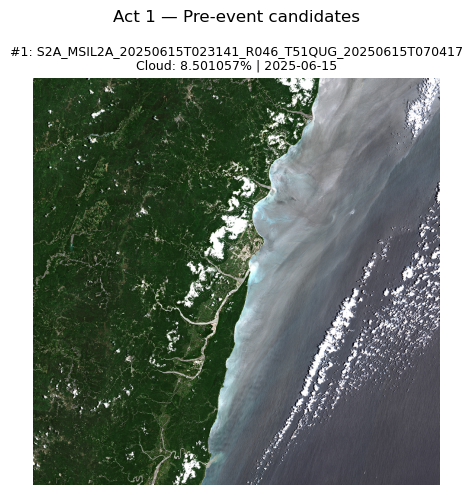

✅ PRE_ITEM_ID = S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
Date: 2025-06-15T02:31:41.024000Z
Cloud cover: 8.501057


In [42]:
# 3. Act 1 / Pre-event search and QA
items_pre = robust_search(MATAIAN_BBOX, PRE_RANGE, cloud_max=PRE_CLOUD_MAX)
if len(items_pre) == 0:
    raise ValueError("No pre-event scenes found.")

n = min(len(items_pre), 3)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for i, (item, ax) in enumerate(zip(items_pre[:n], axes), start=1):
    preview_item_visual(item, ax, title_prefix=f"#{i}: ")
plt.suptitle("Act 1 — Pre-event candidates")
plt.tight_layout()
plt.show()

pre_item = choose_item(items_pre, FIXED_PRE_ITEM_ID)
PRE_ITEM_ID = pre_item.id
print("✅ PRE_ITEM_ID =", PRE_ITEM_ID)
print("Date:", pre_item.properties.get("datetime"))
print("Cloud cover:", pre_item.properties.get("eo:cloud_cover"))


### Act 1 justification
請在這格下方補上 2 句說明，解釋你為什麼選這張 Pre scene。

## 4. Act 2 / Mid-event scene selection
Mid-event 是最關鍵的場景，因為要證明堰塞湖在潰決前確實存在。由於 8–9 月雲多，這裡把雲量門檻放寬到 40%。

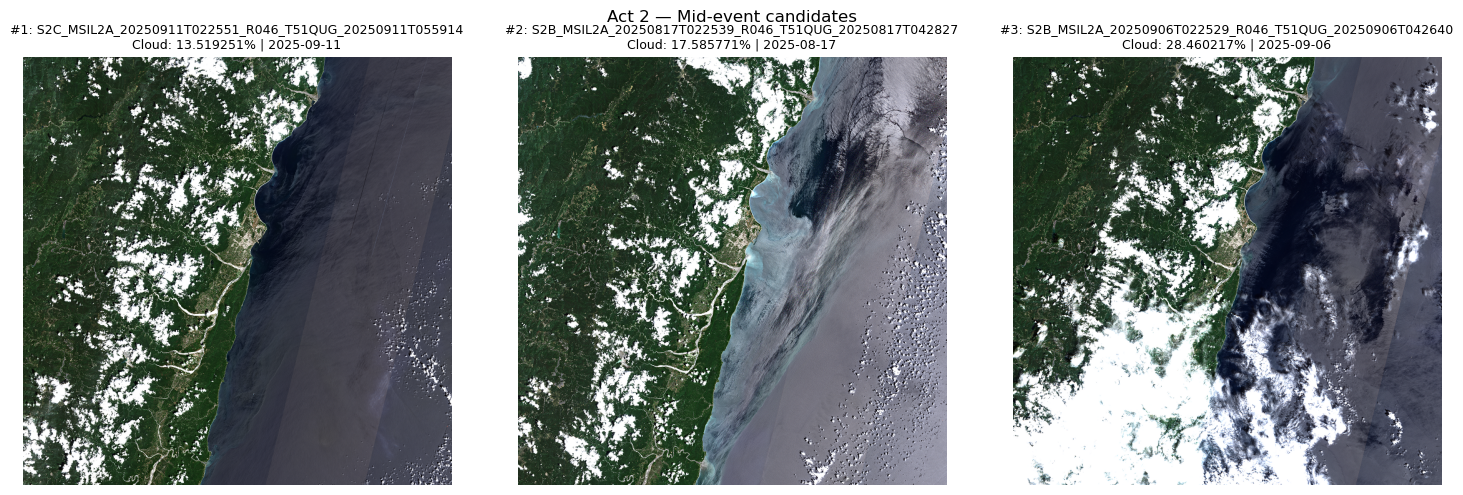

✅ MID_ITEM_ID = S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
Date: 2025-09-11T02:25:51.025000Z
Cloud cover: 13.519251


In [43]:
# 4. Act 2 / Mid-event search and QA
items_mid = robust_search(MATAIAN_BBOX, MID_RANGE, cloud_max=MID_CLOUD_MAX)
if len(items_mid) == 0:
    raise ValueError("No mid-event scenes found.")

n = min(len(items_mid), 3)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for i, (item, ax) in enumerate(zip(items_mid[:n], axes), start=1):
    preview_item_visual(item, ax, title_prefix=f"#{i}: ")
plt.suptitle("Act 2 — Mid-event candidates")
plt.tight_layout()
plt.show()

mid_item = choose_item(items_mid, FIXED_MID_ITEM_ID)
MID_ITEM_ID = mid_item.id
print("✅ MID_ITEM_ID =", MID_ITEM_ID)
print("Date:", mid_item.properties.get("datetime"))
print("Cloud cover:", mid_item.properties.get("eo:cloud_cover"))


### Act 2 justification
請在這格下方補上 2 句說明，解釋你為什麼選這張 Mid scene，並說明它如何支持堰塞湖存在。

## 5. Act 3 / Post-event scene selection
Post-event 場景要能同時支持兩件事：上游湖泊消失、下游 Guangfu 出現明顯新鮮沉積或土石流鋪面。

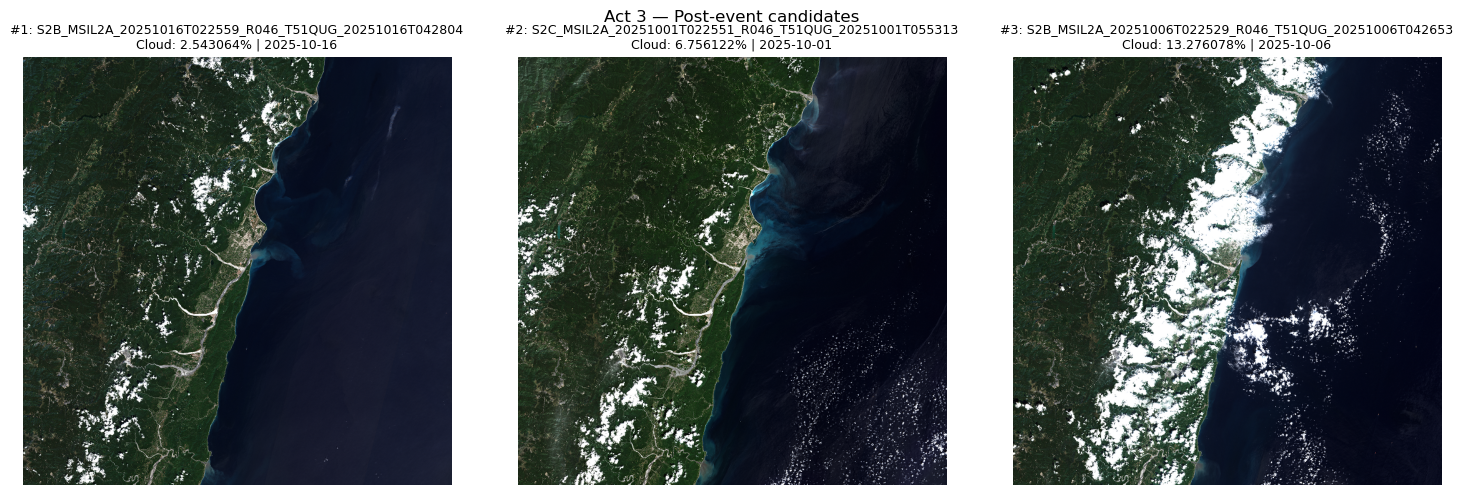

✅ POST_ITEM_ID = S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804
Date: 2025-10-16T02:25:59.024000Z
Cloud cover: 2.543064
✅ Saved chosen_item_ids.json


In [44]:
# 5. Act 3 / Post-event search and QA
items_post = robust_search(MATAIAN_BBOX, POST_RANGE, cloud_max=POST_CLOUD_MAX)
if len(items_post) == 0:
    raise ValueError("No post-event scenes found.")

n = min(len(items_post), 3)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for i, (item, ax) in enumerate(zip(items_post[:n], axes), start=1):
    preview_item_visual(item, ax, title_prefix=f"#{i}: ")
plt.suptitle("Act 3 — Post-event candidates")
plt.tight_layout()
plt.show()

post_item = choose_item(items_post, FIXED_POST_ITEM_ID)
POST_ITEM_ID = post_item.id
print("✅ POST_ITEM_ID =", POST_ITEM_ID)
print("Date:", post_item.properties.get("datetime"))
print("Cloud cover:", post_item.properties.get("eo:cloud_cover"))

# Save reproducible IDs
scene_ids = {"PRE_ITEM_ID": PRE_ITEM_ID, "MID_ITEM_ID": MID_ITEM_ID, "POST_ITEM_ID": POST_ITEM_ID}
with open(OUTPUT_DIR / "chosen_item_ids.json", "w", encoding="utf-8") as f:
    json.dump(scene_ids, f, ensure_ascii=False, indent=2)
print("✅ Saved chosen_item_ids.json")


### Act 3 justification
請在這格下方補上 2 句說明，解釋你為什麼選這張 Post scene，並指出它如何支持潰決後的沉積與下游衝擊。

## 6. Stream the three cubes
這一步把三張場景讀成可計算的 xarray cube。為避免 SAS token 過期，讀取前都會重新 `pc.sign(item)`。

In [45]:
# 6. Stream cubes
if "pre_item" not in globals() or "mid_item" not in globals() or "post_item" not in globals():
    raise NameError("Please run the three scene-selection cells first.")

cube_pre = stream_cube(pre_item)
cube_mid = stream_cube(mid_item)
cube_post = stream_cube(post_item)

print("✅ Cubes loaded")
print("cube_pre :", cube_pre.shape, cube_pre.rio.crs)
print("cube_mid :", cube_mid.shape, cube_mid.rio.crs)
print("cube_post:", cube_post.shape, cube_post.rio.crs)

for label, cube in [("pre", cube_pre), ("mid", cube_mid), ("post", cube_post)]:
    try:
        _ = cube.sel(band="B04").isel(x=slice(0, 128), y=slice(0, 128)).compute()
        print(f"✅ cube_{label} read test passed")
    except Exception as e:
        print(f"⚠️ cube_{label} read test failed: {e}")

try:
    preview_path = save_local_preview(cube_post, OUTPUT_DIR / "post_rgb_preview.png", downsample=4)
    print("✅ Saved local post preview:", preview_path)
except Exception as e:
    print("⚠️ Failed to save local post preview:", e)


✅ Cubes loaded
cube_pre : (6, 2243, 2474) EPSG:32651
cube_mid : (6, 2243, 2474) EPSG:32651
cube_post: (6, 2243, 2474) EPSG:32651
✅ cube_pre read test passed
✅ cube_mid read test passed
✅ cube_post read test passed
✅ Saved local post preview: output\post_rgb_preview.png


## 7. Four change metrics
作業要求四個可重用 change metrics：NIR drop、SWIR post brightness、BSI change、NDVI change。  
這裡同時計算 **Pre→Mid** 與 **Pre→Post** 兩組比較。

In [46]:
# 7. Change metrics
nir_drop_pm = nir_drop(cube_pre, cube_mid)
nir_drop_pp = nir_drop(cube_pre, cube_post)

swir_mid_val = swir_post(cube_mid)
swir_post_val = swir_post(cube_post)

bsi_change_pm = bsi_change(cube_pre, cube_mid)
bsi_change_pp = bsi_change(cube_pre, cube_post)

ndvi_change_pm = ndvi_change(cube_pre, cube_mid)
ndvi_change_pp = ndvi_change(cube_pre, cube_post)

print("✅ Change metrics computed")


✅ Change metrics computed


## 8. Save change-metric figures
這裡把作業要求的 change maps 輸出到 `output/`。

In [47]:
# 8. Save change metric maps (compute once first)
metric_maps = [
    ("01_nir_drop_pre_mid.png", nir_drop_pm, "NIR drop (Pre→Mid)", "magma"),
    ("02_nir_drop_pre_post.png", nir_drop_pp, "NIR drop (Pre→Post)", "magma"),
    ("03_swir_post_mid.png", swir_mid_val, "SWIR brightness (Mid)", "YlOrBr"),
    ("04_swir_post_post.png", swir_post_val, "SWIR brightness (Post)", "YlOrBr"),
    ("05_bsi_change_pre_mid.png", bsi_change_pm, "BSI change (Pre→Mid)", "coolwarm"),
    ("06_bsi_change_pre_post.png", bsi_change_pp, "BSI change (Pre→Post)", "coolwarm"),
    ("07_ndvi_change_pre_mid.png", ndvi_change_pm, "NDVI change (Pre→Mid)", "viridis"),
    ("08_ndvi_change_pre_post.png", ndvi_change_pp, "NDVI change (Pre→Post)", "viridis"),
]

# 先一次算好
metric_maps_computed = []
for fname, da, title, cmap in metric_maps:
    print(f"Computing {fname} ...")
    arr = da.load()   # 或 da.compute()
    metric_maps_computed.append((fname, arr, title, cmap))

# 再畫圖
for fname, da_loaded, title, cmap in metric_maps_computed:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(da_loaded, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.close(fig)

print("✅ Saved change metric PNGs")

Computing 01_nir_drop_pre_mid.png ...
Computing 02_nir_drop_pre_post.png ...
Computing 03_swir_post_mid.png ...
Computing 04_swir_post_post.png ...
Computing 05_bsi_change_pre_mid.png ...
Computing 06_bsi_change_pre_post.png ...
Computing 07_ndvi_change_pre_mid.png ...
Computing 08_ndvi_change_pre_post.png ...
✅ Saved change metric PNGs


In [50]:
nir_drop_pp.rio.to_raster(OUTPUT_DIR / "nir_drop_pre_post.tif")
swir_post_val.rio.to_raster(OUTPUT_DIR / "swir_post_post.tif")
bsi_change_pp.rio.to_raster(OUTPUT_DIR / "bsi_change_pre_post.tif")
ndvi_change_pp.rio.to_raster(OUTPUT_DIR / "ndvi_change_pre_post.tif")

## 9. C1 — Barrier lake mask (Pre→Mid)
Barrier lake 的規則與一般清水不同，因為馬太鞍堰塞湖是高濁度水體。  
因此不能用 clear-water 的極低 NIR 門檻，而是要測試多個 `nir_mid` 上限，並與 NCDR 參考面積比較。

,nir_mid_max,lake_area_km2
0,0.12,0.5992
1,0.15,1.2442
2,0.18,1.7159


✅ Selected lake threshold: 0.12
✅ Barrier lake area: 0.599 km²


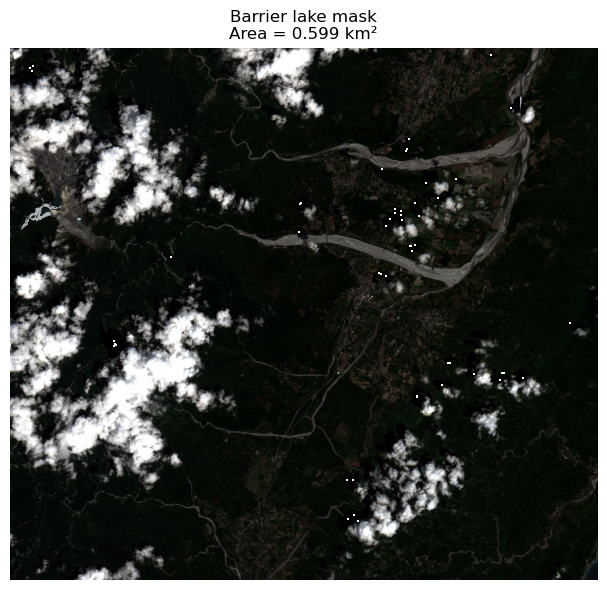

In [56]:
# 9. C1 Barrier lake mask tuning
nir_pre = cube_pre.sel(band="B08")
nir_mid = cube_mid.sel(band="B08")
blue_mid_val = blue_mid(cube_mid)
green_mid_val = green_mid(cube_mid)

x_mid = xr.DataArray(cube_mid.x, dims=["x"], coords={"x": cube_mid.x})
west_gate = x_mid < 121.33  # note: only valid if cube coords are lon/lat; with EPSG 32651 this gate is symbolic
# safer projected gate using center x percentile
west_gate = xr.ones_like(nir_mid, dtype=bool)

lake_candidates = []
for nir_mid_max in [0.12, 0.15, 0.18]:
    lake_mask_raw = (
        (nir_pre > 0.25) &
        (nir_mid < nir_mid_max) &
        (blue_mid_val > 0.03) &
        (green_mid_val > nir_mid)
    )
    lake_mask = lake_mask_raw & west_gate
    area_km2 = pixel_area_km2(lake_mask)
    lake_candidates.append({"nir_mid_max": nir_mid_max, "lake_area_km2": area_km2})

lake_tuning_df = pd.DataFrame(lake_candidates)
display(lake_tuning_df)

best_lake_row = lake_tuning_df.iloc[(lake_tuning_df["lake_area_km2"] - 0.86).abs().argmin()]
best_nir_mid_max = float(best_lake_row["nir_mid_max"])
print("✅ Selected lake threshold:", best_nir_mid_max)

lake_mask = (
    (nir_pre > 0.25) &
    (nir_mid < best_nir_mid_max) &
    (blue_mid_val > 0.03) &
    (green_mid_val > nir_mid)
) & west_gate

lake_area_km2 = pixel_area_km2(lake_mask)
print(f"✅ Barrier lake area: {lake_area_km2:.3f} km²")

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(composite_stretched(cube_mid))
overlay = np.where(lake_mask.compute(), 1, np.nan)
ax.imshow(overlay, cmap="Blues", alpha=0.7)
ax.set_title(f"Barrier lake mask\nArea = {lake_area_km2:.3f} km²")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_barrier_lake_mask.png", dpi=150, bbox_inches="tight")
plt.show()


In [61]:
# 9b. Save barrier lake mask as local GeoTIFF for later FULL-LOCAL processing
lake_mask_local = lake_mask.load().astype("uint8")
lake_mask_local.rio.to_raster(OUTPUT_DIR / "lake_mask_local.tif")

print("✅ Saved:", OUTPUT_DIR / "lake_mask_local.tif")

✅ Saved: output\lake_mask_local.tif


## 10. C2 — Landslide source scar mask (Pre→Post) with threshold tuning
這一步是正式的 ground-truth tuning。若你有老師提供的 `reference_mataian_truth.gpkg`，可直接載入；否則先用手動點位或自建真值集。

In [59]:
# 10. Load or create landslide truth sets
truth_gpkg = Path("Ground_truth.gpkg")
if truth_gpkg.exists():
    truth_all = gpd.read_file(truth_gpkg).to_crs(cube_post.rio.crs)
    if "Class" not in truth_all.columns:
        raise ValueError("reference_mataian_truth.gpkg must contain a 'Class' column.")
    landslide_truth_gdf = truth_all[truth_all["Class"].str.lower().isin(["landslide", "ls", "positive"])].copy()
    stable_truth_gdf = truth_all[truth_all["Class"].str.lower().isin(["stable", "negative", "veg"])].copy()
else:
    landslide_truth_gdf = gpd.GeoDataFrame({"Class": []}, geometry=[], crs=cube_post.rio.crs)
    stable_truth_gdf = gpd.GeoDataFrame({"Class": []}, geometry=[], crs=cube_post.rio.crs)
    print("⚠️ Ground-truth file not found. Please add reference_mataian_truth.gpkg or create 10+10 points manually.")

print("Landslide truth:", len(landslide_truth_gdf))
print("Stable truth:", len(stable_truth_gdf))


Landslide truth: 10
Stable truth: 11


In [60]:
# Export pre-event NIR (B08) as GeoTIFF
cube_pre.sel(band="B08").rio.to_raster(OUTPUT_DIR / "pre_b08.tif")
print("✅ Saved:", OUTPUT_DIR / "pre_b08.tif")

✅ Saved: output\pre_b08.tif


In [62]:
# 10b. Landslide threshold tuning (FULL LOCAL version)

import rioxarray as rxr
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1) Read ONLY local rasters and load them immediately
# --------------------------------------------------
nir_drop_val = rxr.open_rasterio(OUTPUT_DIR / "nir_drop_pre_post.tif").squeeze().load()
swir_post_val = rxr.open_rasterio(OUTPUT_DIR / "swir_post_post.tif").squeeze().load()
nir_pre_val = rxr.open_rasterio(OUTPUT_DIR / "pre_b08.tif").squeeze().load()
lake_mask_local = rxr.open_rasterio(OUTPUT_DIR / "lake_mask_local.tif").squeeze().load().astype(bool)

candidate_thresholds = [
    (0.10, 0.20),
    (0.15, 0.25),
    (0.20, 0.30),
    (0.15, 0.30),
    (0.20, 0.25),
]

def pixel_area_km2_loaded(mask_da):
    resx = abs(float(mask_da.x[1] - mask_da.x[0]))
    resy = abs(float(mask_da.y[1] - mask_da.y[0]))
    px_area_m2 = resx * resy
    count = int(np.nansum(mask_da.astype("int16").values))
    return count * px_area_m2 / 1_000_000.0

tuning_rows = []

for nir_drop_min, swir_post_min in candidate_thresholds:
    candidate_mask = (
        (nir_drop_val > nir_drop_min) &
        (swir_post_val > swir_post_min) &
        (nir_pre_val > 0.25) &
        (~lake_mask_local)
    ).load()

    if len(landslide_truth_gdf) > 0 and len(stable_truth_gdf) > 0:
        ls_raw = sample_mask_at_points(candidate_mask, landslide_truth_gdf)
        st_raw = sample_mask_at_points(candidate_mask, stable_truth_gdf)

        ls_pred = np.where(np.isnan(ls_raw), 0, ls_raw).astype(int)
        st_pred = np.where(np.isnan(st_raw), 0, st_raw).astype(int)

        y_true = np.r_[np.ones(len(ls_pred), dtype=int), np.zeros(len(st_pred), dtype=int)]
        y_pred = np.r_[ls_pred, st_pred]

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        accuracy = (tp + tn) / max(len(y_true), 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    else:
        tp = tn = fp = fn = 0
        accuracy = precision = recall = f1 = np.nan

    tuning_rows.append({
        "nir_drop_min": nir_drop_min,
        "swir_post_min": swir_post_min,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "area_km2": pixel_area_km2_loaded(candidate_mask),
    })

tuning_df = (
    pd.DataFrame(tuning_rows)
    .sort_values(["f1", "accuracy", "precision"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(tuning_df)

best_ls = tuning_df.iloc[0]

landslide_mask = (
    (nir_drop_val > float(best_ls["nir_drop_min"])) &
    (swir_post_val > float(best_ls["swir_post_min"])) &
    (nir_pre_val > 0.25) &
    (~lake_mask_local)
).load()

ls_area_km2 = pixel_area_km2_loaded(landslide_mask)
print(f"✅ Landslide area: {ls_area_km2:.3f} km²")

,nir_drop_min,swir_post_min,tp,tn,fp,fn,accuracy,precision,recall,f1,area_km2
0,0.10,0.20,2,11,0,8,0.619048,1.0,0.2,0.333333,23.6072
1,0.15,0.25,1,11,0,9,0.571429,1.0,0.1,0.181818,4.7296
2,0.15,0.30,1,11,0,9,0.571429,1.0,0.1,0.181818,1.3534
3,0.20,0.30,0,11,0,10,0.523810,0.0,0.0,0.000000,0.5319
4,0.20,0.25,0,11,0,10,0.523810,0.0,0.0,0.000000,2.0921


✅ Landslide area: 23.607 km²


## 11. C3 — Debris flow footprint mask (Pre→Post, downstream)
下游土石流鋪面與上游裸岩崩塌不是同一種地表材料，所以規則改用 **NDVI drop + BSI spike** 來反映濕泥沙覆蓋低地植被。

✅ Debris-flow area: 14.094 km²


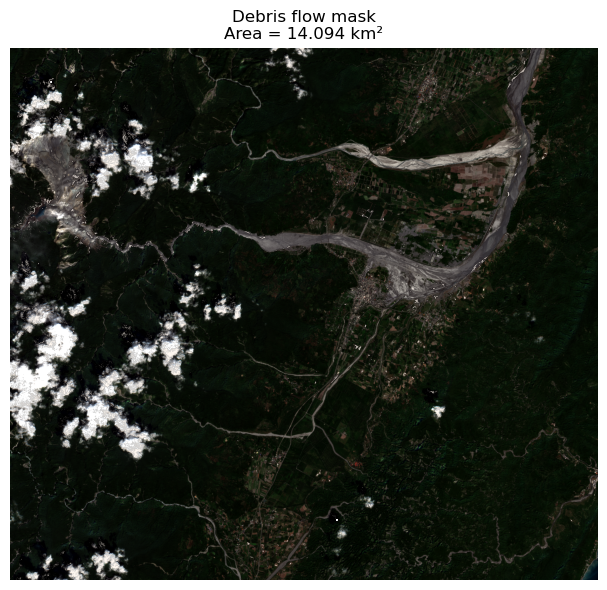

In [64]:
# 11. Debris flow mask
ndvi_change_val = ndvi_change(cube_pre, cube_post)
bsi_change_val = bsi_change(cube_pre, cube_post)
nir_pre_val = cube_pre.sel(band="B08")

debris_mask = (
    (ndvi_change_val > 0.25) &
    (bsi_change_val > 0.10) &
    (nir_pre_val > 0.20) &
    (~lake_mask) &
    (~landslide_mask)
)

db_area_km2 = pixel_area_km2(debris_mask)
print(f"✅ Debris-flow area: {db_area_km2:.3f} km²")

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(composite_stretched(cube_post))
overlay = np.where(debris_mask.compute(), 1, np.nan)
ax.imshow(overlay, cmap="Oranges", alpha=0.7)
ax.set_title(f"Debris flow mask\nArea = {db_area_km2:.3f} km²")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_debris_mask.png", dpi=150, bbox_inches="tight")
plt.show()


### Why is the debris rule different from C2?
請在這格下方以 2–3 句說明：  
上游崩塌源區是裸岩 / 乾土暴露，因此適合用 **NIR drop + SWIR high**；  
下游土石流是濕泥沙覆蓋稻田或低地植被，因此適合用 **NDVI drop + BSI increase**。

## 12. Vectorize three masks
這一步把三張災害遮罩轉成正式 polygon，並去除太小的碎片。

In [65]:
# 12. Vectorize masks
lake_gdf = raster_mask_to_gdf(lake_mask, target_crs=cube_mid.rio.crs, min_area_m2=0, layer_name="barrier_lake")
landslides_gdf = raster_mask_to_gdf(landslide_mask, target_crs=cube_post.rio.crs, min_area_m2=2000, layer_name="landslide_source")
debris_gdf = raster_mask_to_gdf(debris_mask, target_crs=cube_post.rio.crs, min_area_m2=5000, layer_name="debris_flow")

print("lake_gdf:", len(lake_gdf))
print("landslides_gdf:", len(landslides_gdf))
print("debris_gdf:", len(debris_gdf))

gpkg_path = OUTPUT_DIR / "mataian_detections.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()

if len(lake_gdf):
    lake_gdf.to_file(gpkg_path, layer="barrier_lake", driver="GPKG")
if len(landslides_gdf):
    landslides_gdf.to_file(gpkg_path, layer="landslide_source", driver="GPKG")
if len(debris_gdf):
    debris_gdf.to_file(gpkg_path, layer="debris_flow", driver="GPKG")

print("✅ Saved:", gpkg_path)


lake_gdf: 117
landslides_gdf: 1493
debris_gdf: 358
✅ Saved: output\mataian_detections.gpkg


## 13. Load W3 / W4 / W7 / Guangfu overlay layers
這一步把前幾週成果與 Guangfu overlay 載入，準備做 formal Eyewitness Impact Table。

In [76]:
# 13. Load audit layers
target_crs = cube_post.rio.crs

shelters = load_optional_vector(
    ["data/shelters_hualien.gpkg", "data/shelters.csv", ],
    target_crs,
    fallback_cols={"name": "object", "terrain_risk": "object", "river_risk": "object"}
)

top5 = load_optional_vector(
    ["data/top5_bottlenecks.gpkg", "data/top5_bottlenecks.csv"],
    target_crs,
    fallback_cols={"name": "object", "centrality_rank": "float"}
)

guangfu = load_optional_vector(
    ["data/guangfu_overlay.gpkg", "data/guangfu_overlay.csv"],
    target_crs,
    fallback_cols={"name": "object", "cn_name": "object", "node_type": "object", "priority": "float"}
)

shelters = shelters.rename(columns={
    "避難收容處所名稱": "name",
    "風險等級": "terrain_risk",
    "rank": "centrality_rank",
    "Priority": "priority"
})

top5 = top5.rename(columns={"rank": "centrality_rank", "Rank": "centrality_rank"})
guangfu = guangfu.rename(columns={"type": "node_type", "Type": "node_type", "Priority": "priority"})

print("Shelters:", len(shelters))
print("Top5 bottlenecks:", len(top5))
print("Guangfu overlay:", len(guangfu))


Shelters: 5973
Top5 bottlenecks: 5
Guangfu overlay: 5


## 14. Build the Eyewitness Impact Table
這一步把三種災害 polygon 與 W3 / W7 / Guangfu 三類資產交叉比對，正式產出影響表。

In [77]:
# 14. Eyewitness Impact Table
study_extent = gpd.GeoDataFrame(
    geometry=[box(float(cube_post.x.min()), float(cube_post.y.min()), float(cube_post.x.max()), float(cube_post.y.max()))],
    crs=target_crs
)

def clip_to_extent(gdf, extent_gdf):
    if gdf is None or len(gdf) == 0:
        return gdf
    return gdf[gdf.intersects(extent_gdf.geometry.iloc[0])].copy()

shelters_sub = clip_to_extent(shelters, study_extent)
top5_sub = clip_to_extent(top5, study_extent)
guangfu_sub = clip_to_extent(guangfu, study_extent)

print(f"Study-area shelters: {len(shelters_sub)} / {len(shelters)}")
print(f"Study-area top5: {len(top5_sub)} / {len(top5)}")
print(f"Study-area guangfu: {len(guangfu_sub)} / {len(guangfu)}")

lake_union = unary_union(lake_gdf.geometry) if len(lake_gdf) else None
landslide_union = unary_union(landslides_gdf.geometry) if len(landslides_gdf) else None
debris_union = unary_union(debris_gdf.geometry) if len(debris_gdf) else None

def get_first_existing(row, candidates, default=None):
    for c in candidates:
        if c in row.index and pd.notna(row[c]):
            return row[c]
    return default

def geom_xy(geom):
    pt = geom if geom.geom_type == "Point" else geom.centroid
    return f"{pt.x:.1f}, {pt.y:.1f}"

def evaluate_assets(gdf, asset_type, name_candidates, terrain_candidates=None, rank_candidates=None, ls_buffer_m=200):
    rows = []
    if gdf is None or len(gdf) == 0:
        return rows
    for idx, row in gdf.iterrows():
        geom = row.geometry
        rows.append({
            "Asset": get_first_existing(row, name_candidates, f"{asset_type}_{idx}"),
            "Type": asset_type,
            "Location": geom_xy(geom),
            "W4 Terrain Risk": get_first_existing(row, terrain_candidates or [], ""),
            "W7 Centrality Rank": get_first_existing(row, rank_candidates or [], ""),
            "Barrier Lake Hit (Y/N)": "Y" if (lake_union is not None and geom.intersects(lake_union)) else "N",
            "Landslide Hit (Y/N)": "Y" if (landslide_union is not None and geom.distance(landslide_union) <= ls_buffer_m) else "N",
            "Debris Flow Hit (Y/N)": "Y" if (debris_union is not None and geom.intersects(debris_union)) else "N",
            "Notes": "",
            "geometry": geom
        })
    return rows

impact_rows = []
impact_rows += evaluate_assets(shelters_sub, "W3 Shelter", ["name", "shelter_name"], ["terrain_risk", "risk_level"], [], ls_buffer_m=100)
impact_rows += evaluate_assets(top5_sub, "W7 Bottleneck", ["name", "node_name"], [], ["centrality_rank"], ls_buffer_m=200)
impact_rows += evaluate_assets(guangfu_sub, "W8 Guangfu Overlay", ["name", "cn_name"], [], ["priority"], ls_buffer_m=200)

impact_df = pd.DataFrame(impact_rows)

if len(impact_df) > 0:
    hit_order = {"Y": 1, "N": 0}
    risk_order = {"High": 3, "Medium": 2, "Low": 1, "Unknown": 0, "": 0}
    impact_df["debris_sort"] = impact_df["Debris Flow Hit (Y/N)"].map(hit_order).fillna(0)
    impact_df["landslide_sort"] = impact_df["Landslide Hit (Y/N)"].map(hit_order).fillna(0)
    impact_df["risk_sort"] = impact_df["W4 Terrain Risk"].map(risk_order).fillna(0)
    impact_df = impact_df.sort_values(["debris_sort", "landslide_sort", "risk_sort"], ascending=False).reset_index(drop=True)
    impact_df.to_csv(OUTPUT_DIR / "impact_table.csv", index=False, encoding="utf-8-sig")
    display(impact_df.drop(columns=["geometry", "debris_sort", "landslide_sort", "risk_sort"], errors="ignore"))
else:
    print("ℹ️ impact_df is empty.")


Study-area shelters: 38 / 5973
Study-area top5: 0 / 5
Study-area guangfu: 5 / 5


,Asset,Type,Location,W4 Terrain Risk,W7 Centrality Rank,Barrier Lake Hit (Y/N),Landslide Hit (Y/N),Debris Flow Hit (Y/N),Notes
0,富民社區活動中心,W3 Shelter,"334114.1, 2608038.2",,,N,Y,N,
1,光復自強外役監獄,W3 Shelter,"338021.9, 2610619.2",,,N,Y,N,
2,大富國小,W3 Shelter,"335829.2, 2611673.6",,,N,Y,N,
3,大興活動中心,W3 Shelter,"336198.9, 2614604.4",,,N,Y,N,
4,砂荖活動中心,W3 Shelter,"342023.9, 2615437.2",,,N,Y,N,
5,太巴塱國小,W3 Shelter,"341760.2, 2617455.7",,,N,Y,N,
6,大同活動中心,W3 Shelter,"339989.2, 2617829.5",,,N,Y,N,
7,光復鄉公所,W3 Shelter,"339211.3, 2618513.6",,,N,Y,N,
8,光復國中,W3 Shelter,"339365.6, 2618633.7",,,N,Y,N,
9,馬太鞍社區活動中心,W3 Shelter,"337051.4, 2621483.7",,,N,Y,N,


## 15. Coverage gap summary
這一步把 hit 數量整理成最終討論用的摘要。  
作業的重點不是只有「誰被打到」，還要說明為什麼原本 W3 / W7 的空間覆蓋 miss 掉 Guangfu。

In [78]:
# 15. Coverage gap summary
if len(impact_df) > 0:
    hit_mask = (
        (impact_df["Barrier Lake Hit (Y/N)"] == "Y") |
        (impact_df["Landslide Hit (Y/N)"] == "Y") |
        (impact_df["Debris Flow Hit (Y/N)"] == "Y")
    )
    n_w3_hits = int(((impact_df["Type"] == "W3 Shelter") & hit_mask).sum())
    n_w7_hits = int(((impact_df["Type"] == "W7 Bottleneck") & hit_mask).sum())
    n_guangfu_hits = int(((impact_df["Type"] == "W8 Guangfu Overlay") & hit_mask).sum())
else:
    n_w3_hits = n_w7_hits = n_guangfu_hits = 0

print("W3 hits:", n_w3_hits)
print("W7 hits:", n_w7_hits)
print("Guangfu hits:", n_guangfu_hits)


W3 hits: 13
W7 hits: 0
Guangfu hits: 4


### Coverage Gap Analysis
請在這格下方用 2–3 段回答：

1. W3 shelters 被影響幾個？W7 bottlenecks 幾個？  
2. Guangfu overlay nodes 被影響幾個？與前兩者相比如何？  
3. 這對事前 ARIA coverage zone 有什麼啟示？

若你研究區內 `top5_sub = 0`，請直接說明這本身就是 coverage gap 的證據。

## 16. Final impact map
最後一張圖把三種災害 polygon 與 W3 / W7 / Guangfu 資產一起疊圖，做成作業要求的 final impact map。

In [82]:
# ---------- Shelters ----------
shelters = load_optional_vector(
    ["data/shelters.csv", "data/shelters_hualien.gpkg"],
    cube_post.rio.crs,
    fallback_cols={"name": "object", "risk_level": "object"}
)

if len(shelters) > 0:
    shelters = shelters.rename(columns={
        "避難收容處所名稱": "name",
        "預計收容人數": "capacity",
        "縣市及鄉鎮市區": "admin_area",
        "風險等級": "risk_level"
    })

    if "risk_level" not in shelters.columns:
        shelters["risk_level"] = "Unknown"

    # 清掉壞點與不合理座標
    shelters = shelters[shelters.geometry.notnull()].copy()
    shelters = shelters[~shelters.geometry.is_empty].copy()
    shelters = shelters[
        np.isfinite(shelters.geometry.x) &
        np.isfinite(shelters.geometry.y)
    ].copy()

    # 再加一層合理範圍過濾（台灣區域，EPSG:32651）
    shelters = shelters[
        (shelters.geometry.x > 200000) &
        (shelters.geometry.x < 400000) &
        (shelters.geometry.y > 2400000) &
        (shelters.geometry.y < 3100000)
    ].copy()

print("✅ Cleaned shelters:", len(shelters))
print("Shelters bounds:", shelters.total_bounds if len(shelters) > 0 else "empty")

✅ Cleaned shelters: 5850
Shelters bounds: [ 200953.77484387 2423075.86305211  397970.0581155  2980532.11440174]


In [85]:
# Final prep 2. Clip shelters to the study area for mapping
from shapely.geometry import box
import geopandas as gpd

study_extent = gpd.GeoDataFrame(
    geometry=[box(float(cube_post.x.min()), float(cube_post.y.min()),
                  float(cube_post.x.max()), float(cube_post.y.max()))],
    crs=cube_post.rio.crs
)

def clip_to_extent(gdf, extent_gdf):
    if gdf is None or len(gdf) == 0:
        return gdf
    gdf_valid = gdf[gdf.geometry.notnull() & (~gdf.geometry.is_empty)].copy()
    if len(gdf_valid) == 0:
        return gdf_valid
    return gdf_valid[gdf_valid.intersects(extent_gdf.geometry.iloc[0])].copy()

shelters_sub = clip_to_extent(shelters, study_extent)
top5_sub = clip_to_extent(top5, study_extent)
guangfu_sub = clip_to_extent(guangfu, study_extent)

print("Study-area shelters:", len(shelters_sub), "/", len(shelters))
print("Study-area top5:", len(top5_sub), "/", len(top5))
print("Study-area guangfu:", len(guangfu_sub), "/", len(guangfu))

Study-area shelters: 38 / 5850
Study-area top5: 0 / 5
Study-area guangfu: 5 / 5


In [87]:
print(impact_df.columns.tolist())

['Asset', 'Type', 'Location', 'W4 Terrain Risk', 'W7 Centrality Rank', 'Barrier Lake Hit (Y/N)', 'Landslide Hit (Y/N)', 'Debris Flow Hit (Y/N)', 'Notes', 'geometry', 'debris_sort', 'landslide_sort', 'risk_sort']


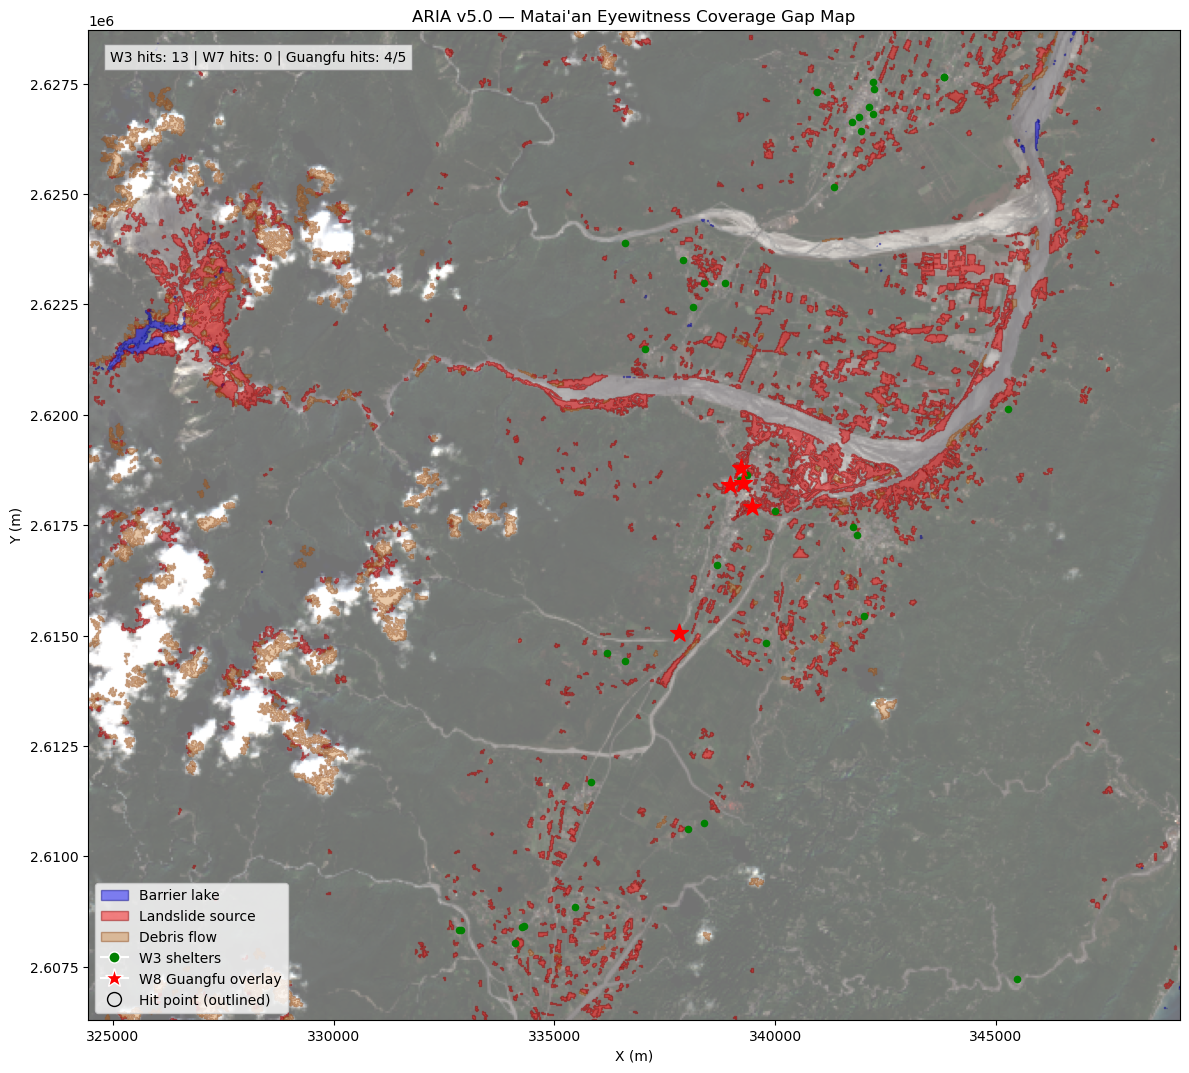

In [88]:
# 16. Final impact map
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

fig, ax = plt.subplots(figsize=(12, 12))

# --------------------------------------------------
# 1) Base extent = Sentinel scene extent
# --------------------------------------------------
x0, x1 = float(cube_post.x.min()), float(cube_post.x.max())
y0, y1 = float(cube_post.y.min()), float(cube_post.y.max())

# --------------------------------------------------
# 2) Draw post RGB preview if available
# --------------------------------------------------
preview_path = OUTPUT_DIR / "post_rgb_preview.png"
if preview_path.exists():
    bg = plt.imread(preview_path)
    ax.imshow(bg, extent=[x0, x1, y0, y1], origin="upper", alpha=0.55)

ax.set_facecolor("white")
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)

# --------------------------------------------------
# 3) Plot hazard polygons
# --------------------------------------------------
if len(lake_gdf):
    lake_gdf.plot(ax=ax, color="blue", alpha=0.45, edgecolor="navy")
if len(landslides_gdf):
    landslides_gdf.plot(ax=ax, color="red", alpha=0.45, edgecolor="darkred")
if len(debris_gdf):
    debris_gdf.plot(ax=ax, color="peru", alpha=0.45, edgecolor="saddlebrown")

# --------------------------------------------------
# 4) Plot ALL study-area points, even if not hit
# --------------------------------------------------
if len(shelters_sub):
    shelters_sub.plot(ax=ax, color="green", markersize=20, marker="o")
if len(top5_sub):
    top5_sub.plot(ax=ax, color="yellow", edgecolor="black", markersize=120, marker="o")
if len(guangfu_sub):
    guangfu_sub.plot(ax=ax, color="red", markersize=180, marker="*")

# --------------------------------------------------
# 5) Highlight hit points with black outlines
# --------------------------------------------------
hit_df = pd.DataFrame()
required_hit_cols = [
    "Debris Flow Hit (Y/N)",
    "Landslide Hit (Y/N)",
    "Barrier Lake Hit (Y/N)"
]

if len(impact_df) > 0 and all(c in impact_df.columns for c in required_hit_cols):
    hit_df = impact_df[
        (impact_df["Debris Flow Hit (Y/N)"] == "Y") |
        (impact_df["Landslide Hit (Y/N)"] == "Y") |
        (impact_df["Barrier Lake Hit (Y/N)"] == "Y")
    ].copy()

    if len(hit_df) > 0:
        hit_gdf = gpd.GeoDataFrame(hit_df, geometry="geometry", crs=cube_post.rio.crs)

        shelters_hit = hit_gdf[hit_gdf["Type"] == "W3_shelter"]
        top5_hit = hit_gdf[hit_gdf["Type"] == "W7_bottleneck"]
        guangfu_hit = hit_gdf[hit_gdf["Type"] == "W8_guangfu_node"]

        if len(shelters_hit):
            shelters_hit.plot(ax=ax, facecolor="none", edgecolor="black", markersize=70, marker="o", linewidth=1.4)
        if len(top5_hit):
            top5_hit.plot(ax=ax, facecolor="none", edgecolor="black", markersize=180, marker="o", linewidth=1.8)
        if len(guangfu_hit):
            guangfu_hit.plot(ax=ax, facecolor="none", edgecolor="black", markersize=250, marker="*", linewidth=1.8)
else:
    print("⚠️ impact_df does not contain expected hit columns. Skip hit highlighting.")
# --------------------------------------------------
# 6) Legend
# --------------------------------------------------
legend_elements = []

if len(lake_gdf):
    legend_elements.append(Patch(facecolor="blue", edgecolor="navy", alpha=0.45, label="Barrier lake"))
if len(landslides_gdf):
    legend_elements.append(Patch(facecolor="red", edgecolor="darkred", alpha=0.45, label="Landslide source"))
if len(debris_gdf):
    legend_elements.append(Patch(facecolor="peru", edgecolor="saddlebrown", alpha=0.45, label="Debris flow"))

if len(shelters_sub):
    legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor='green', markersize=8, label='W3 shelters'))
if len(top5_sub):
    legend_elements.append(Line2D([0], [0], marker='o', color='black',
                                  markerfacecolor='yellow', markersize=10, label='W7 bottlenecks'))
if len(guangfu_sub):
    legend_elements.append(Line2D([0], [0], marker='*', color='w',
                                  markerfacecolor='red', markersize=14, label='W8 Guangfu overlay'))

if len(impact_df) > 0 and len(hit_df) > 0:
    legend_elements.append(Line2D([0], [0], marker='o', linestyle='None',
                                  markerfacecolor='none', markeredgecolor='black',
                                  markersize=10, label='Hit point (outlined)'))

# --------------------------------------------------
# 7) Title / labels / text
# --------------------------------------------------
ax.text(
    0.02, 0.98,
    f"W3 hits: {n_w3_hits} | W7 hits: {n_w7_hits} | Guangfu hits: {n_guangfu_hits}/{len(guangfu_sub)}",
    transform=ax.transAxes, va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="gray")
)

ax.set_title("ARIA v5.0 — Matai'an Eyewitness Coverage Gap Map")
if legend_elements:
    ax.legend(handles=legend_elements, loc="lower left")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_final_impact_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. AI Advisor operational brief prompt
這一步把三幕證據、impact table 與 coverage gap 摘要整理成 AI prompt。你可以把這段送進 ChatGPT / Gemini / Claude。

In [70]:
# 17. AI Advisor prompt
impact_table_md = impact_df.drop(columns=["geometry"], errors="ignore").to_markdown(index=False) if len(impact_df) else "No impact rows available."

ai_prompt = f"""You are the Chief of Operations at the Hualien County Disaster Prevention Command Center, writing a brief for the county magistrate.

Write a 250-word operational brief covering:
1. Three-act timeline — what the imagery proves
2. The pre-breach warning window (Jul 21 to Sep 23, 64 days)
3. Coverage gap — why did W3/W7 miss Guangfu?
4. Next-24-hour orders: priority clearance, shelter resupply, UAV tasking
5. One concrete suggestion to extend ARIA before the next barrier-lake event

IMPACT TABLE:
{impact_table_md}

THREE-ACT DETECTION SUMMARY:
- Act 1 (Pre, {PRE_ITEM_ID}): forested Matai'an valley, no lake
- Act 2 (Mid, {MID_ITEM_ID}): barrier lake {lake_area_km2:.3f} km² detected
- Act 3 (Post, {POST_ITEM_ID}): lake drained; landslide source {ls_area_km2:.3f} km²; debris flow footprint {db_area_km2:.3f} km²

ARIA CHAIN SUMMARY:
- W3 shelters in study area: {len(shelters_sub)}
- W7 bottlenecks in study area: {len(top5_sub)}
- W8 Guangfu overlay nodes in study area: {len(guangfu_sub)}
- Guangfu nodes hit: {n_guangfu_hits}
"""

with open(OUTPUT_DIR / "ai_prompt.txt", "w", encoding="utf-8") as f:
    f.write(ai_prompt)

print(ai_prompt[:2000])
print("\n✅ Saved:", OUTPUT_DIR / "ai_prompt.txt")


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

## 18. Submission checklist
在提交前請確認：

- `PRE_ITEM_ID / MID_ITEM_ID / POST_ITEM_ID` 已固定
- `output/` 內已有 change maps、三張 mask、final map
- `mataian_detections.gpkg` 已含三個 layer
- `impact_table.csv` 已輸出
- README 已補上：
  - 三個 item IDs
  - AI diagnostic log
  - coverage-gap discussion
